# Notebook 1C — Low-cost climate data collection

This notebook is the climate-data analogue of Notebook 1S.

It collects a balanced, low-cost climate layer for medicinal plant occurrence space using:

- GBIF occurrence records;
- taxon-balanced spatial-block sampling;
- NASA POWER climatology point queries;
- cache reuse;
- derived bioclimatic-like climate features.

The default workflow is CPU-only and does not download large climate rasters.

Main outputs:

- `derived/occurrence_climate_features.tsv`
- `climate/climate_point_features_long.tsv`
- `climate/climate_point_features_wide.tsv`
- `derived/climate_taxon_summary.tsv`
- `derived/climate_spatial_block_features.tsv`
- `derived/climate_coverage_by_taxon_v1.tsv`
- `derived/climate_notebook1C_handoff_manifest.tsv`

Interpretation: this notebook produces an open-data climate-niche layer. It does not prove climate causes metabolite accumulation.

In [1]:
# ============================================================
# 0. Imports
# ============================================================

import os
import re
import json
import time
import pathlib
import warnings
import datetime as dt

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 220)

In [2]:
# ============================================================
# 1. Configuration
# ============================================================

CONFIG = {
    "project_dir": "climate_medicinal_value_dataset_v1",
    "resume_from_existing_outputs": True,
    "input_dirs": [
        ".",
        "/content",
        "/mnt/data",
        "/content/soilgrids_medicinal_value_dataset_v3_low_cost",
        "/content/soilgrids_medicinal_value_dataset_v3_low_cost/gbif",
        "/content/soilgrids_medicinal_value_dataset_v3_low_cost/derived",
        "/content/soilgrids_medicinal_value_dataset",
        "/content/soilgrids_medicinal_value_dataset/gbif",
        "/content/soilgrids_medicinal_value_dataset/derived",
        "/content/climate_medicinal_value_dataset_v1",
    ],

    "gbif_occurrence_limit_per_taxon": 1000,
    "gbif_occurrence_country": "",
    "gbif_liberal_coordinate_uncertainty_m": 10000,
    "gbif_strict_coordinate_uncertainty_m": 1000,
    "gbif_preferred_basis_of_record": ["PRESERVED_SPECIMEN", "MATERIAL_SAMPLE", "LIVING_SPECIMEN"],

    "spatial_block_degrees": 0.25,
    "target_climate_blocks_per_taxon": 40,
    "max_new_climate_points_this_run": None,

    "power_base_url": "https://power.larc.nasa.gov/api/temporal/climatology/point",
    "power_community": "AG",
    "power_format": "JSON",
    "power_parameters": [
        "T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR",
        "RH2M", "ALLSKY_SFC_SW_DWN", "WS2M"
    ],

    "request_sleep_seconds": 0.15,
    "request_retries": 5,
    "checkpoint_every_n_points": 20,

    "min_climate_blocks_per_taxon_for_notebook2": 30,
    "min_occurrences_covered_per_taxon_for_notebook2": 80,

    "figure_dpi": 300,
    "save_pdf": True,
    "random_seed": 42,
}

TARGET_TAXA = [
    {"taxon_id": "TAX_SEDUM", "scientific_name": "Sedum", "rank": "genus", "family": "Crassulaceae", "priority": "project_core"},
    {"taxon_id": "TAX_RHODIOLA", "scientific_name": "Rhodiola", "rank": "genus", "family": "Crassulaceae", "priority": "project_core"},
    {"taxon_id": "TAX_HYPERICUM", "scientific_name": "Hypericum", "rank": "genus", "family": "Hypericaceae", "priority": "project_core"},
    {"taxon_id": "TAX_ARTEMISIA_ANNUA", "scientific_name": "Artemisia annua", "rank": "species", "family": "Asteraceae", "priority": "positive_control"},
    {"taxon_id": "TAX_GLYCYRRHIZA_GLABRA", "scientific_name": "Glycyrrhiza glabra", "rank": "species", "family": "Fabaceae", "priority": "positive_control"},
    {"taxon_id": "TAX_TAXUS", "scientific_name": "Taxus", "rank": "genus", "family": "Taxaceae", "priority": "positive_control"},
]

TARGET_COMPOUNDS = [
    {"compound_id": "CMP_SALIDROSIDE", "compound_name": "salidroside", "compound_class": "phenolic glycoside", "record_type": "molecule", "relevant_taxa": "Rhodiola"},
    {"compound_id": "CMP_TYROSOL", "compound_name": "tyrosol", "compound_class": "phenolic alcohol", "record_type": "molecule", "relevant_taxa": "Rhodiola"},
    {"compound_id": "CMP_HYPERICIN", "compound_name": "hypericin", "compound_class": "naphthodianthrone", "record_type": "molecule", "relevant_taxa": "Hypericum"},
    {"compound_id": "CMP_ARTEMISININ", "compound_name": "artemisinin", "compound_class": "sesquiterpene lactone", "record_type": "molecule", "relevant_taxa": "Artemisia"},
    {"compound_id": "CMP_GLYCYRRHIZIN", "compound_name": "glycyrrhizin", "compound_class": "triterpenoid saponin", "record_type": "molecule", "relevant_taxa": "Glycyrrhiza"},
    {"compound_id": "CMP_PACLITAXEL", "compound_name": "paclitaxel", "compound_class": "diterpenoid taxane", "record_type": "molecule", "relevant_taxa": "Taxus"},
    {"compound_id": "CMP_TOTAL_FLAVONOIDS", "compound_name": "flavonoids", "compound_class": "flavonoids", "record_type": "compound_class", "relevant_taxa": "broad plants"},
    {"compound_id": "CMP_TOTAL_PHENOLICS", "compound_name": "phenolic compounds", "compound_class": "phenolic compounds", "record_type": "compound_class", "relevant_taxa": "broad plants"},
]

PROJECT = pathlib.Path(CONFIG["project_dir"]).resolve()
DIRS = {
    "metadata": PROJECT / "metadata",
    "gbif": PROJECT / "gbif",
    "climate": PROJECT / "climate",
    "derived": PROJECT / "derived",
    "figures": PROJECT / "figures",
    "logs": PROJECT / "logs",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

RUN_ID = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%dT%H%M%SZ")
CONFIG["run_id"] = RUN_ID
CONFIG["created_utc"] = dt.datetime.now(dt.timezone.utc).isoformat(timespec="seconds")

pd.DataFrame(TARGET_TAXA).to_csv(DIRS["metadata"] / "target_taxa_config.tsv", sep="\t", index=False)
pd.DataFrame(TARGET_COMPOUNDS).to_csv(DIRS["metadata"] / "target_compounds_config.tsv", sep="\t", index=False)

with open(PROJECT / "notebook1C_climate_config.json", "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2, ensure_ascii=False)

PROJECT

PosixPath('/content/climate_medicinal_value_dataset_v1')

In [3]:
# ============================================================
# 2. Utility functions
# ============================================================

SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "medicinal-plant-climate-niche-v1/1.0"})

def utc_now():
    return dt.datetime.now(dt.timezone.utc).isoformat(timespec="seconds")

def safe_name(x, max_len=180):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(x)).strip("_")[:max_len]

def write_table(df, path_stem):
    path_stem.parent.mkdir(parents=True, exist_ok=True)
    tsv = path_stem.with_suffix(".tsv")
    df.to_csv(tsv, sep="\t", index=False)
    try:
        df.to_parquet(path_stem.with_suffix(".parquet"), index=False)
    except Exception as e:
        print(f"Parquet skipped for {path_stem.name}: {e}")
    return tsv

def save_figure(fig, name):
    png = DIRS["figures"] / f"{safe_name(name)}.png"
    fig.savefig(png, dpi=CONFIG["figure_dpi"], bbox_inches="tight")
    if CONFIG["save_pdf"]:
        fig.savefig(DIRS["figures"] / f"{safe_name(name)}.pdf", bbox_inches="tight")
    print("Saved:", png)
    return png

def find_existing_file(filename):
    candidates = []
    for d in CONFIG["input_dirs"]:
        d = pathlib.Path(d)
        candidates.append(d / filename)
        if d.exists() and d.is_dir():
            candidates.extend(d.rglob(filename))
    existing = sorted(set([p for p in candidates if p.exists() and p.stat().st_size > 0]), key=lambda p: (len(str(p)), str(p)))
    return existing[0] if existing else None

def load_existing_tsv(filename):
    p = find_existing_file(filename)
    if p is None:
        return pd.DataFrame()
    print(f"Loaded existing {filename} from {p}")
    return pd.read_csv(p, sep="\t", dtype=str, low_memory=False)

def request_get_json(url, params=None, retries=None, sleep=None, timeout=120):
    retries = CONFIG["request_retries"] if retries is None else retries
    sleep = CONFIG["request_sleep_seconds"] if sleep is None else sleep
    last_error = None
    for i in range(retries):
        try:
            r = SESSION.get(url, params=params, timeout=timeout)
            if r.status_code in [429, 500, 502, 503, 504]:
                last_error = f"HTTP {r.status_code}: {r.text[:300]}"
                time.sleep(sleep * (2 ** i))
                continue
            r.raise_for_status()
            time.sleep(sleep)
            return r.json()
        except Exception as e:
            last_error = str(e)
            time.sleep(sleep * (2 ** i))
    raise RuntimeError(f"GET failed: {url} params={params}; last_error={last_error}")

def add_provenance(df, source, query):
    df = df.copy()
    df["source"] = source
    df["query"] = query
    df["retrieved_utc"] = utc_now()
    df["run_id"] = RUN_ID
    return df

def cache_file(point_id):
    return DIRS["climate"] / "api_cache" / f"{safe_name(point_id)}__nasa_power_climatology.json"

def find_cached_climate_json(point_id):
    possible_name = f"{safe_name(point_id)}__nasa_power_climatology.json"
    possible_dirs = [DIRS["climate"] / "api_cache"]
    for d in CONFIG["input_dirs"]:
        d = pathlib.Path(d)
        possible_dirs.append(d / "api_cache")
        possible_dirs.append(d / "climate" / "api_cache")
    for d in possible_dirs:
        p = d / possible_name
        if p.exists() and p.stat().st_size > 0:
            return p
    return None

def has_cached_climate(point_id):
    return find_cached_climate_json(point_id) is not None

def read_cached_climate(point_id):
    p = find_cached_climate_json(point_id)
    if p is None:
        return None
    return json.loads(p.read_text(encoding="utf-8"))

In [4]:
# ============================================================
# 3. Load or collect GBIF occurrence records
# ============================================================

GBIF_OCCURRENCE_SEARCH = "https://api.gbif.org/v1/occurrence/search"
GBIF_SPECIES_MATCH = "https://api.gbif.org/v1/species/match"

def gbif_match_taxon(name):
    return request_get_json(GBIF_SPECIES_MATCH, params={"name": name})

def gbif_occurrences(scientific_name, limit=1000, country=""):
    match = gbif_match_taxon(scientific_name)
    taxon_key = match.get("usageKey") or match.get("acceptedUsageKey")
    if not taxon_key:
        return pd.DataFrame([{"scientific_name_query": scientific_name, "gbif_error": match.get("error", "no taxon key")}])

    rows = []
    page_limit = min(300, limit)
    offset = 0

    while offset < limit:
        params = {"taxonKey": taxon_key, "hasCoordinate": "true", "limit": page_limit, "offset": offset}
        if country:
            params["country"] = country

        data = request_get_json(GBIF_OCCURRENCE_SEARCH, params=params, timeout=120)

        for rec in data.get("results", []):
            rows.append({
                "gbif_key": rec.get("key"),
                "taxon_key": taxon_key,
                "scientific_name_query": scientific_name,
                "scientific_name": rec.get("scientificName"),
                "accepted_scientific_name": rec.get("acceptedScientificName"),
                "country": rec.get("country"),
                "country_code": rec.get("countryCode"),
                "decimal_latitude": rec.get("decimalLatitude"),
                "decimal_longitude": rec.get("decimalLongitude"),
                "coordinate_uncertainty_m": rec.get("coordinateUncertaintyInMeters"),
                "event_date": rec.get("eventDate"),
                "basis_of_record": rec.get("basisOfRecord"),
                "institution_code": rec.get("institutionCode"),
                "dataset_key": rec.get("datasetKey"),
                "has_geospatial_issue": rec.get("hasGeospatialIssues"),
                "last_interpreted": rec.get("lastInterpreted"),
                "gbif_match_taxon_key": taxon_key,
                "gbif_match_status": match.get("matchType"),
                "gbif_match_confidence": match.get("confidence"),
            })

        if data.get("endOfRecords", False):
            break
        offset += page_limit

    df = pd.DataFrame(rows)
    if not df.empty:
        df = add_provenance(df, "GBIF occurrence API", f"taxonKey={taxon_key}; country={country or 'global'}")
    return df

existing_gbif = load_existing_tsv("gbif_occurrence_manifest.tsv")

if CONFIG["resume_from_existing_outputs"] and not existing_gbif.empty:
    gbif_df = existing_gbif.copy()
else:
    tables = []
    for tax in tqdm(TARGET_TAXA, desc="GBIF taxa"):
        df = gbif_occurrences(tax["scientific_name"], limit=CONFIG["gbif_occurrence_limit_per_taxon"], country=CONFIG["gbif_occurrence_country"])
        if not df.empty:
            df["taxon_id"] = tax["taxon_id"]
            df["input_taxon"] = tax["scientific_name"]
            df["family"] = tax["family"]
            df["rank"] = tax["rank"]
            df["priority"] = tax["priority"]
            tables.append(df)
    gbif_df = pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()

if not gbif_df.empty and "gbif_key" in gbif_df.columns:
    gbif_df = gbif_df.drop_duplicates(subset=["gbif_key"])

write_table(gbif_df, DIRS["gbif"] / "gbif_occurrence_manifest")
print("GBIF rows:", len(gbif_df))
gbif_df.head()

GBIF taxa:   0%|          | 0/6 [00:00<?, ?it/s]

GBIF rows: 7200


,gbif_key,taxon_key,scientific_name_query,scientific_name,accepted_scientific_name,country,country_code,decimal_latitude,decimal_longitude,coordinate_uncertainty_m,event_date,basis_of_record,institution_code,dataset_key,has_geospatial_issue,last_interpreted,gbif_match_taxon_key,gbif_match_status,gbif_match_confidence,source,query,retrieved_utc,run_id,taxon_id,input_taxon,family,rank,priority
0,5938030633,5361975,Sedum,Sedum hispanicum L.,Sedum hispanicum L.,Italy,IT,46.216905,13.222121,26.0,2026-01-03T13:21:21,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T22:15:06.327+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T06:31:18+00:00,20260515T063115Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core
1,5938036248,5361975,Sedum,Sedum album L.,Sedum album L.,France,FR,43.283052,5.370825,NaN,2026-01-04T17:49,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T22:06:16.452+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T06:31:18+00:00,20260515T063115Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core
2,5938040436,5361975,Sedum,Sedum dasyphyllum L.,Sedum dasyphyllum L.,France,FR,43.284080,5.369642,NaN,2026-01-04T17:57,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T21:54:48.819+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T06:31:18+00:00,20260515T063115Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core
3,5938047369,5361975,Sedum,Sedum sexangulare L.,Sedum sexangulare L.,Hungary,HU,47.902580,19.758109,4.0,2026-01-01T14:27:50,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T22:04:41.071+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T06:31:18+00:00,20260515T063115Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core
4,5938050053,5361975,Sedum,Sedum dasyphyllum L.,Sedum dasyphyllum L.,France,FR,43.283152,5.370802,NaN,2026-01-04T17:48,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T21:53:43.866+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T06:31:18+00:00,20260515T063115Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core


In [5]:
# ============================================================
# 4. Coordinate QC and spatial blocks
# ============================================================

def filter_gbif(df, uncertainty_threshold_m, specimen_only=False):
    if df.empty:
        return pd.DataFrame()

    out = df.copy()
    out["decimal_latitude"] = pd.to_numeric(out["decimal_latitude"], errors="coerce")
    out["decimal_longitude"] = pd.to_numeric(out["decimal_longitude"], errors="coerce")
    out["coordinate_uncertainty_m"] = pd.to_numeric(out["coordinate_uncertainty_m"], errors="coerce")

    keep = (
        out["decimal_latitude"].between(-90, 90) &
        out["decimal_longitude"].between(-180, 180) &
        (~out["has_geospatial_issue"].astype(str).str.lower().isin(["true", "1", "yes"])) &
        (out["coordinate_uncertainty_m"].isna() | (out["coordinate_uncertainty_m"] <= uncertainty_threshold_m))
    )

    if specimen_only:
        keep = keep & out["basis_of_record"].isin(CONFIG["gbif_preferred_basis_of_record"])

    out = out[keep].copy()

    block = CONFIG["spatial_block_degrees"]
    out["spatial_block_lat"] = np.floor(out["decimal_latitude"] / block).astype("Int64")
    out["spatial_block_lon"] = np.floor(out["decimal_longitude"] / block).astype("Int64")
    out["spatial_block_id"] = out["spatial_block_lat"].astype(str) + "_" + out["spatial_block_lon"].astype(str)
    out["block_centroid_latitude"] = (out["spatial_block_lat"].astype(float) + 0.5) * block
    out["block_centroid_longitude"] = (out["spatial_block_lon"].astype(float) + 0.5) * block

    out["abs_latitude"] = out["decimal_latitude"].abs()
    out["latitudinal_band"] = pd.cut(
        out["decimal_latitude"],
        bins=[-90, -60, -35, -23.5, 0, 23.5, 35, 60, 90],
        labels=["antarctic_subpolar", "south_temperate", "south_subtropical", "south_tropical",
                "north_tropical", "north_subtropical", "north_temperate", "arctic_subpolar"],
        include_lowest=True
    ).astype(str)
    out["longitude_sector_30deg"] = np.floor((out["decimal_longitude"] + 180) / 30).astype("Int64").astype(str)
    out["geo_stratum"] = out["latitudinal_band"].astype(str) + "__lonsec_" + out["longitude_sector_30deg"].astype(str)

    return out

gbif_liberal_df = filter_gbif(gbif_df, CONFIG["gbif_liberal_coordinate_uncertainty_m"], specimen_only=False)
gbif_strict_df = filter_gbif(gbif_df, CONFIG["gbif_strict_coordinate_uncertainty_m"], specimen_only=False)
gbif_strict_specimen_df = filter_gbif(gbif_df, CONFIG["gbif_strict_coordinate_uncertainty_m"], specimen_only=True)

write_table(gbif_liberal_df, DIRS["gbif"] / "gbif_occurrence_liberal_filtered")
write_table(gbif_strict_df, DIRS["gbif"] / "gbif_occurrence_strict_filtered")
write_table(gbif_strict_specimen_df, DIRS["gbif"] / "gbif_occurrence_strict_specimen")

gbif_qc_df = pd.DataFrame([
    {"metric": "raw_records", "value": len(gbif_df)},
    {"metric": "liberal_filtered_records", "value": len(gbif_liberal_df)},
    {"metric": "strict_filtered_records", "value": len(gbif_strict_df)},
    {"metric": "strict_specimen_records", "value": len(gbif_strict_specimen_df)},
    {"metric": "liberal_spatial_blocks", "value": gbif_liberal_df["spatial_block_id"].nunique()},
])
write_table(gbif_qc_df, DIRS["gbif"] / "gbif_occurrence_qc_summary")
display(gbif_qc_df)

,metric,value
0,raw_records,7200
1,liberal_filtered_records,7032
2,strict_filtered_records,6115
3,strict_specimen_records,132
4,liberal_spatial_blocks,2523


In [6]:
# ============================================================
# 5. Low-cost stratified climate sampling design
# ============================================================

if gbif_liberal_df.empty:
    raise RuntimeError("No liberal GBIF records available.")

rng = np.random.default_rng(CONFIG["random_seed"])

taxon_block_df = (
    gbif_liberal_df
    .groupby(["taxon_id", "input_taxon", "family", "rank", "priority", "spatial_block_id", "geo_stratum"], as_index=False)
    .agg(
        n_occurrences_in_taxon_block=("gbif_key", "count"),
        decimal_latitude=("block_centroid_latitude", "first"),
        decimal_longitude=("block_centroid_longitude", "first"),
        mean_abs_latitude=("abs_latitude", "mean"),
    )
)

taxon_block_df["point_id"] = "CBLOCK_" + taxon_block_df["spatial_block_id"].astype(str)
taxon_block_df["has_cached_climate"] = taxon_block_df["point_id"].apply(has_cached_climate)
taxon_block_df["random_tiebreaker"] = rng.random(len(taxon_block_df))

selected_rows = []
quota = int(CONFIG["target_climate_blocks_per_taxon"])

for taxon_id, sub in taxon_block_df.groupby("taxon_id"):
    stratum_best = (
        sub.sort_values(["has_cached_climate", "n_occurrences_in_taxon_block", "random_tiebreaker"], ascending=[False, False, True])
        .groupby("geo_stratum", as_index=False)
        .head(1)
        .copy()
    )
    remaining = sub[~sub["spatial_block_id"].isin(stratum_best["spatial_block_id"])].copy()
    remaining = remaining.sort_values(["has_cached_climate", "n_occurrences_in_taxon_block", "random_tiebreaker"], ascending=[False, False, True])
    chosen = pd.concat([stratum_best, remaining], ignore_index=True).head(quota)
    selected_rows.append(chosen)

selected_taxon_block_df = pd.concat(selected_rows, ignore_index=True) if selected_rows else pd.DataFrame()

point_df = (
    selected_taxon_block_df
    .sort_values(["has_cached_climate", "n_occurrences_in_taxon_block"], ascending=[False, False])
    .drop_duplicates(subset=["spatial_block_id"])
    .copy()
)
point_df["point_id"] = "CBLOCK_" + point_df["spatial_block_id"].astype(str)
point_df["query_level"] = "low_cost_stratified_taxon_climate_block"
point_df["already_cached"] = point_df["point_id"].apply(has_cached_climate)

new_point_df = point_df[~point_df["already_cached"]].copy()
if CONFIG["max_new_climate_points_this_run"] is not None:
    new_point_df = new_point_df.head(int(CONFIG["max_new_climate_points_this_run"])).copy()

cached_selected_df = point_df[point_df["already_cached"]].copy()
query_point_df = pd.concat([cached_selected_df, new_point_df], ignore_index=True).drop_duplicates(subset=["point_id"])

write_table(taxon_block_df, DIRS["climate"] / "climate_taxon_block_candidates_v1")
write_table(selected_taxon_block_df, DIRS["climate"] / "climate_selected_taxon_blocks_stratified_v1")
write_table(point_df, DIRS["climate"] / "climate_query_points_all_selected_v1")
write_table(query_point_df, DIRS["climate"] / "climate_query_points")

sampling_plan_df = (
    selected_taxon_block_df
    .groupby(["taxon_id", "input_taxon"], as_index=False)
    .agg(
        selected_taxon_blocks=("spatial_block_id", "nunique"),
        selected_geo_strata=("geo_stratum", "nunique"),
        selected_cached_taxon_blocks=("has_cached_climate", "sum"),
        selected_occurrences_represented=("n_occurrences_in_taxon_block", "sum"),
    )
)
sampling_plan_df["target_blocks_per_taxon"] = quota
sampling_plan_df["selected_cached_taxon_blocks"] = sampling_plan_df["selected_cached_taxon_blocks"].astype(int)

write_table(sampling_plan_df, DIRS["climate"] / "climate_low_cost_sampling_plan_by_taxon_v1")

print("Unique climate points selected:", len(point_df))
print("New NASA POWER API calls required:", len(new_point_df))
display(sampling_plan_df)

Unique climate points selected: 222
New NASA POWER API calls required: 222


,taxon_id,input_taxon,selected_taxon_blocks,selected_geo_strata,selected_cached_taxon_blocks,selected_occurrences_represented,target_blocks_per_taxon
0,TAX_ARTEMISIA_ANNUA,Artemisia annua,40,19,0,488,40
1,TAX_GLYCYRRHIZA_GLABRA,Glycyrrhiza glabra,40,7,0,453,40
2,TAX_HYPERICUM,Hypericum,40,29,0,294,40
3,TAX_RHODIOLA,Rhodiola,40,18,0,416,40
4,TAX_SEDUM,Sedum,40,19,0,390,40
5,TAX_TAXUS,Taxus,40,11,0,536,40


In [7]:
# ============================================================
# 6. NASA POWER climatology query and feature derivation
# ============================================================

cache_dir = DIRS["climate"] / "api_cache"
cache_dir.mkdir(parents=True, exist_ok=True)
checkpoint_dir = DIRS["climate"] / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

MONTHS = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]

def power_climatology_query(lon, lat):
    params = {
        "parameters": ",".join(CONFIG["power_parameters"]),
        "community": CONFIG["power_community"],
        "longitude": float(lon),
        "latitude": float(lat),
        "format": CONFIG["power_format"],
    }
    return request_get_json(CONFIG["power_base_url"], params=params, timeout=120)

def parse_power_climatology_response(js, point_id, lon, lat):
    rows = []
    parameters = js.get("properties", {}).get("parameter", {})
    if not isinstance(parameters, dict):
        return rows
    for param, values in parameters.items():
        if not isinstance(values, dict):
            continue
        for period, value in values.items():
            try:
                val = float(value)
            except Exception:
                val = np.nan
            rows.append({
                "point_id": point_id,
                "decimal_longitude": lon,
                "decimal_latitude": lat,
                "climate_parameter": param,
                "period": str(period),
                "value": val,
            })
    return rows

def derive_climate_features(point_long_df):
    rows = []
    for point_id, sub in point_long_df.groupby("point_id"):
        out = {"point_id": point_id}
        out["decimal_longitude"] = pd.to_numeric(sub["decimal_longitude"], errors="coerce").iloc[0]
        out["decimal_latitude"] = pd.to_numeric(sub["decimal_latitude"], errors="coerce").iloc[0]

        wide = sub.pivot_table(index="period", columns="climate_parameter", values="value", aggfunc="first")

        def month_series(param):
            if param not in wide.columns:
                return pd.Series(index=MONTHS, dtype=float)
            return pd.to_numeric(wide[param].reindex(MONTHS), errors="coerce")

        tmean = month_series("T2M")
        tmax = month_series("T2M_MAX")
        tmin = month_series("T2M_MIN")
        precip = month_series("PRECTOTCORR")
        rh = month_series("RH2M")
        solar = month_series("ALLSKY_SFC_SW_DWN")
        wind = month_series("WS2M")

        out["clim_tmean_annual"] = tmean.mean()
        out["clim_tmean_seasonality_sd"] = tmean.std()
        out["clim_tmean_range"] = tmean.max() - tmean.min()
        out["clim_tmax_warmest_month"] = tmax.max()
        out["clim_tmin_coldest_month"] = tmin.min()
        out["clim_temp_extreme_range"] = tmax.max() - tmin.min()
        out["clim_mean_diurnal_range"] = (tmax - tmin).mean()

        out["clim_precip_annual"] = precip.sum()
        out["clim_precip_wettest_month"] = precip.max()
        out["clim_precip_driest_month"] = precip.min()
        out["clim_precip_seasonality_cv"] = 100 * precip.std() / precip.mean() if precip.mean() != 0 else np.nan
        out["clim_aridity_index_precip_over_tmean_plus10"] = precip.sum() / (tmean.mean() + 10) if pd.notna(tmean.mean()) else np.nan

        p_ext = pd.concat([precip, precip.iloc[:2]], ignore_index=True)
        t_ext = pd.concat([tmean, tmean.iloc[:2]], ignore_index=True)
        quarter_precip = pd.Series([p_ext.iloc[i:i+3].sum() for i in range(12)], index=MONTHS)
        quarter_temp = pd.Series([t_ext.iloc[i:i+3].mean() for i in range(12)], index=MONTHS)

        wet_q = quarter_precip.idxmax() if quarter_precip.notna().any() else None
        dry_q = quarter_precip.idxmin() if quarter_precip.notna().any() else None
        warm_q = quarter_temp.idxmax() if quarter_temp.notna().any() else None
        cold_q = quarter_temp.idxmin() if quarter_temp.notna().any() else None

        out["clim_precip_wettest_quarter"] = quarter_precip.max()
        out["clim_precip_driest_quarter"] = quarter_precip.min()
        out["clim_tmean_warmest_quarter"] = quarter_temp.max()
        out["clim_tmean_coldest_quarter"] = quarter_temp.min()
        out["clim_tmean_wettest_quarter"] = quarter_temp.loc[wet_q] if wet_q is not None else np.nan
        out["clim_tmean_driest_quarter"] = quarter_temp.loc[dry_q] if dry_q is not None else np.nan
        out["clim_precip_warmest_quarter"] = quarter_precip.loc[warm_q] if warm_q is not None else np.nan
        out["clim_precip_coldest_quarter"] = quarter_precip.loc[cold_q] if cold_q is not None else np.nan

        out["clim_rh2m_annual"] = rh.mean()
        out["clim_rh2m_seasonality_sd"] = rh.std()
        out["clim_solar_annual_mean"] = solar.mean()
        out["clim_solar_seasonality_sd"] = solar.std()
        out["clim_wind_annual_mean"] = wind.mean()
        out["clim_wind_seasonality_sd"] = wind.std()

        for m in MONTHS:
            out[f"clim_T2M_{m}"] = tmean.loc[m] if m in tmean.index else np.nan
            out[f"clim_PRECTOTCORR_{m}"] = precip.loc[m] if m in precip.index else np.nan
            out[f"clim_RH2M_{m}"] = rh.loc[m] if m in rh.index else np.nan

        rows.append(out)

    return pd.DataFrame(rows)

In [8]:
# ============================================================
# 7. Run NASA POWER climatology queries
# ============================================================

climate_rows = []
error_rows = []

print("Unique selected climate points:", len(point_df))
print("Points loaded/queried this run:", len(query_point_df))
print("New API calls needed:", int((~query_point_df["point_id"].apply(has_cached_climate)).sum()))

for i, (_, p) in enumerate(tqdm(query_point_df.iterrows(), total=len(query_point_df), desc="NASA POWER climatology points")):
    pid = p["point_id"]
    lon = float(p["decimal_longitude"])
    lat = float(p["decimal_latitude"])

    try:
        js = read_cached_climate(pid)
        if js is None:
            js = power_climatology_query(lon, lat)
            cache_file(pid).write_text(json.dumps(js, indent=2), encoding="utf-8")

        climate_rows.extend(parse_power_climatology_response(js, pid, lon, lat))

    except Exception as e:
        error_rows.append({"point_id": pid, "error_type": "nasa_power_climatology_query", "error": str(e), "lon": lon, "lat": lat})

    if (i + 1) % CONFIG["checkpoint_every_n_points"] == 0:
        pd.DataFrame(climate_rows).to_csv(checkpoint_dir / "climate_point_features_long_checkpoint.tsv", sep="\t", index=False)
        pd.DataFrame(error_rows).to_csv(checkpoint_dir / "climate_query_errors_checkpoint.tsv", sep="\t", index=False)
        print(f"Checkpoint {i+1}: climate rows={len(climate_rows)}, errors={len(error_rows)}")

climate_long_df = pd.DataFrame(climate_rows)
if not climate_long_df.empty:
    climate_long_df = climate_long_df.merge(query_point_df[["point_id", "spatial_block_id", "query_level"]], on="point_id", how="left")
    climate_long_df["source"] = "NASA POWER Climatology API"
    climate_long_df["query"] = "/api/temporal/climatology/point"
    climate_long_df["retrieved_utc"] = utc_now()
    climate_long_df["run_id"] = RUN_ID

climate_error_df = pd.DataFrame(error_rows)
if not climate_error_df.empty:
    climate_error_df["source"] = "NASA POWER Climatology API"
    climate_error_df["retrieved_utc"] = utc_now()
    climate_error_df["run_id"] = RUN_ID

write_table(climate_long_df, DIRS["climate"] / "climate_point_features_long")
write_table(climate_error_df, DIRS["climate"] / "climate_query_errors")

climate_features_wide_df = derive_climate_features(climate_long_df) if not climate_long_df.empty else pd.DataFrame()
if not climate_features_wide_df.empty:
    climate_features_wide_df = climate_features_wide_df.merge(query_point_df[["point_id", "spatial_block_id", "query_level"]], on="point_id", how="left")

write_table(climate_features_wide_df, DIRS["climate"] / "climate_point_features_wide")

print("Climate long rows:", len(climate_long_df))
print("Climate wide table:", climate_features_wide_df.shape)
print("Errors:", len(climate_error_df))
display(climate_features_wide_df.head())

Unique selected climate points: 222
Points loaded/queried this run: 222
New API calls needed: 222


NASA POWER climatology points:   0%|          | 0/222 [00:00<?, ?it/s]

Checkpoint 20: climate rows=1820, errors=0
Checkpoint 40: climate rows=3640, errors=0
Checkpoint 60: climate rows=5460, errors=0
Checkpoint 80: climate rows=7280, errors=0
Checkpoint 100: climate rows=9100, errors=0
Checkpoint 120: climate rows=10920, errors=0
Checkpoint 140: climate rows=12740, errors=0
Checkpoint 160: climate rows=14560, errors=0
Checkpoint 180: climate rows=16380, errors=0
Checkpoint 200: climate rows=18200, errors=0
Checkpoint 220: climate rows=20020, errors=0
Climate long rows: 20202
Climate wide table: (222, 67)
Errors: 0


,point_id,decimal_longitude,decimal_latitude,clim_tmean_annual,clim_tmean_seasonality_sd,clim_tmean_range,clim_tmax_warmest_month,clim_tmin_coldest_month,clim_temp_extreme_range,clim_mean_diurnal_range,clim_precip_annual,clim_precip_wettest_month,clim_precip_driest_month,clim_precip_seasonality_cv,clim_aridity_index_precip_over_tmean_plus10,clim_precip_wettest_quarter,clim_precip_driest_quarter,clim_tmean_warmest_quarter,clim_tmean_coldest_quarter,clim_tmean_wettest_quarter,clim_tmean_driest_quarter,clim_precip_warmest_quarter,clim_precip_coldest_quarter,clim_rh2m_annual,clim_rh2m_seasonality_sd,clim_solar_annual_mean,clim_solar_seasonality_sd,clim_wind_annual_mean,clim_wind_seasonality_sd,clim_T2M_JAN,clim_PRECTOTCORR_JAN,clim_RH2M_JAN,clim_T2M_FEB,clim_PRECTOTCORR_FEB,clim_RH2M_FEB,clim_T2M_MAR,clim_PRECTOTCORR_MAR,clim_RH2M_MAR,clim_T2M_APR,clim_PRECTOTCORR_APR,clim_RH2M_APR,clim_T2M_MAY,clim_PRECTOTCORR_MAY,clim_RH2M_MAY,clim_T2M_JUN,clim_PRECTOTCORR_JUN,clim_RH2M_JUN,clim_T2M_JUL,clim_PRECTOTCORR_JUL,clim_RH2M_JUL,clim_T2M_AUG,clim_PRECTOTCORR_AUG,clim_RH2M_AUG,clim_T2M_SEP,clim_PRECTOTCORR_SEP,clim_RH2M_SEP,clim_T2M_OCT,clim_PRECTOTCORR_OCT,clim_RH2M_OCT,clim_T2M_NOV,clim_PRECTOTCORR_NOV,clim_RH2M_NOV,clim_T2M_DEC,clim_PRECTOTCORR_DEC,clim_RH2M_DEC,spatial_block_id,query_level
0,CBLOCK_-104_113,28.375,-25.875,17.107500,4.463287,11.75,38.75,-4.75,43.50,31.182500,21.13,4.09,0.09,83.889953,0.779489,11.01,0.55,21.490000,11.000000,21.270000,11.000000,10.94,0.55,55.250000,8.742662,20.454167,3.733401,2.330000,0.407230,21.64,3.95,65.13,21.38,2.90,64.06,19.86,2.36,63.04,16.67,1.44,62.21,13.32,0.51,54.12,10.03,0.23,54.65,9.89,0.09,49.19,13.08,0.23,43.61,17.34,0.53,38.95,19.91,1.83,48.19,20.72,2.97,56.51,21.45,4.09,63.34,-104_113,low_cost_stratified_taxon_climate_block
1,CBLOCK_-118_-202,-50.375,-29.375,17.306667,3.503853,9.60,35.25,-2.86,38.11,27.511667,51.56,5.32,3.43,12.478360,1.888184,14.53,11.25,21.456667,12.986667,17.046667,15.213333,13.04,12.47,82.765000,1.718654,16.134167,5.009305,0.408333,0.025525,21.84,4.55,81.32,21.78,4.53,81.60,20.54,4.09,82.24,18.11,3.43,82.68,14.56,4.00,84.92,12.97,3.82,85.69,12.24,4.63,84.44,13.75,4.02,83.05,15.09,5.32,83.51,17.35,5.05,83.03,18.70,4.16,80.79,20.75,3.96,79.91,-118_-202,low_cost_stratified_taxon_climate_block
2,CBLOCK_-120_122,30.625,-29.875,18.172500,2.817301,7.96,41.14,2.19,38.95,28.395833,46.35,6.85,0.85,61.766394,1.645221,20.47,3.38,21.406667,14.436667,20.600000,14.436667,17.11,3.38,78.739167,6.047089,16.994167,3.223678,2.464167,0.348932,21.67,6.83,85.03,21.77,5.80,85.41,20.78,4.48,84.85,18.55,2.80,81.96,16.55,1.35,75.72,14.17,0.85,70.76,13.81,1.28,69.52,15.33,1.25,71.07,17.06,3.01,75.20,18.25,5.06,79.14,19.35,6.85,81.87,20.78,6.79,84.34,-120_122,low_cost_stratified_taxon_climate_block
3,CBLOCK_-126_602,150.625,-31.375,16.901667,5.969033,16.75,44.08,-3.01,47.09,32.162500,23.04,3.09,1.05,38.095027,0.856453,8.35,3.76,24.013333,9.276667,24.013333,10.716667,8.35,4.33,65.018333,8.273394,19.048333,6.017550,2.282500,0.244582,25.23,2.38,55.22,23.80,2.88,60.32,20.96,2.30,64.61,17.01,1.20,67.97,12.47,1.05,71.11,9.55,1.88,80.09,8.48,1.21,77.22,9.80,1.24,69.69,13.87,1.31,62.42,17.70,1.80,57.67,20.94,2.70,57.13,23.01,3.09,56.77,-126_602,low_cost_stratified_taxon_climate_block
4,CBLOCK_-127_602,150.625,-31.625,16.901667,5.969033,16.75,44.08,-3.01,47.09,32.162500,23.04,3.09,1.05,38.095027,0.856453,8.35,3.76,24.013333,9.276667,24.013333,10.716667,8.35,4.33,65.018333,8.273394,19.048333,6.017550,2.282500,0.244582,25.23,2.38,55.22,23.80,2.88,60.32,20.96,2.30,64.61,17.01,1.20,67.97,12.47,1.05,71.11,9.55,1.88,80.09,8.48,1.21,77.22,9.80,1.24,69.69,13.87,1.31,62.42,17.70,1.80,57.67,20.94,2.70,57.13,23.01,3.09,56.77,-127_602,low_cost_stratified_taxon_climate_block


In [9]:
# ============================================================
# 8. Join climate features to selected occurrences
# ============================================================

selected_occ_df = gbif_liberal_df[
    gbif_liberal_df["spatial_block_id"].astype(str).isin(set(climate_features_wide_df["spatial_block_id"].astype(str)))
].copy()

occ_climate_df = selected_occ_df.merge(
    climate_features_wide_df.drop(columns=["decimal_longitude", "decimal_latitude"], errors="ignore"),
    on="spatial_block_id",
    how="left"
)

climate_feature_cols = [c for c in occ_climate_df.columns if c.startswith("clim_")]

if climate_feature_cols:
    occ_climate_df["has_any_climate"] = occ_climate_df[climate_feature_cols].apply(
        lambda row: pd.to_numeric(row, errors="coerce").notna().any(), axis=1
    )
else:
    occ_climate_df["has_any_climate"] = False

gbif_liberal_df["in_low_cost_climate_sample"] = gbif_liberal_df["spatial_block_id"].astype(str).isin(
    set(climate_features_wide_df["spatial_block_id"].astype(str))
)

write_table(occ_climate_df, DIRS["derived"] / "occurrence_climate_features")
write_table(gbif_liberal_df, DIRS["derived"] / "gbif_liberal_with_climate_sample_flag_v1")

print("Occurrence-climate table:", occ_climate_df.shape)
print("Climate features:", len(climate_feature_cols))
display(occ_climate_df.head())

Occurrence-climate table: (2763, 102)
Climate features: 62


,gbif_key,taxon_key,scientific_name_query,scientific_name,accepted_scientific_name,country,country_code,decimal_latitude,decimal_longitude,coordinate_uncertainty_m,event_date,basis_of_record,institution_code,dataset_key,has_geospatial_issue,last_interpreted,gbif_match_taxon_key,gbif_match_status,gbif_match_confidence,source,query,retrieved_utc,run_id,taxon_id,input_taxon,family,rank,priority,spatial_block_lat,spatial_block_lon,spatial_block_id,block_centroid_latitude,block_centroid_longitude,abs_latitude,latitudinal_band,longitude_sector_30deg,geo_stratum,point_id,clim_tmean_annual,clim_tmean_seasonality_sd,clim_tmean_range,clim_tmax_warmest_month,clim_tmin_coldest_month,clim_temp_extreme_range,clim_mean_diurnal_range,clim_precip_annual,clim_precip_wettest_month,clim_precip_driest_month,clim_precip_seasonality_cv,clim_aridity_index_precip_over_tmean_plus10,clim_precip_wettest_quarter,clim_precip_driest_quarter,clim_tmean_warmest_quarter,clim_tmean_coldest_quarter,clim_tmean_wettest_quarter,clim_tmean_driest_quarter,clim_precip_warmest_quarter,clim_precip_coldest_quarter,clim_rh2m_annual,clim_rh2m_seasonality_sd,clim_solar_annual_mean,clim_solar_seasonality_sd,clim_wind_annual_mean,clim_wind_seasonality_sd,clim_T2M_JAN,clim_PRECTOTCORR_JAN,clim_RH2M_JAN,clim_T2M_FEB,clim_PRECTOTCORR_FEB,clim_RH2M_FEB,clim_T2M_MAR,clim_PRECTOTCORR_MAR,clim_RH2M_MAR,clim_T2M_APR,clim_PRECTOTCORR_APR,clim_RH2M_APR,clim_T2M_MAY,clim_PRECTOTCORR_MAY,clim_RH2M_MAY,clim_T2M_JUN,clim_PRECTOTCORR_JUN,clim_RH2M_JUN,clim_T2M_JUL,clim_PRECTOTCORR_JUL,clim_RH2M_JUL,clim_T2M_AUG,clim_PRECTOTCORR_AUG,clim_RH2M_AUG,clim_T2M_SEP,clim_PRECTOTCORR_SEP,clim_RH2M_SEP,clim_T2M_OCT,clim_PRECTOTCORR_OCT,clim_RH2M_OCT,clim_T2M_NOV,clim_PRECTOTCORR_NOV,clim_RH2M_NOV,clim_T2M_DEC,clim_PRECTOTCORR_DEC,clim_RH2M_DEC,query_level,has_any_climate
0,5938036248,5361975,Sedum,Sedum album L.,Sedum album L.,France,FR,43.283052,5.370825,NaN,2026-01-04T17:49,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T22:06:16.452+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T06:31:18+00:00,20260515T063115Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core,173,21,173_21,43.375,5.375,43.283052,north_temperate,6,north_temperate__lonsec_6,CBLOCK_173_21,14.170000,7.175193,19.33,40.98,-8.02,49.00,28.265833,18.31,3.13,0.42,47.600477,0.757551,7.30,2.06,23.516667,5.723333,10.336667,23.516667,2.06,4.66,70.220833,11.886903,15.965833,7.825818,3.038333,0.145592,5.32,1.56,84.06,5.74,1.35,80.61,8.89,1.28,75.86,12.45,1.57,71.30,16.55,1.52,66.15,21.82,0.97,57.52,24.65,0.42,51.08,24.08,0.67,53.04,19.53,1.67,63.12,15.12,2.42,74.52,9.78,3.13,81.62,6.11,1.75,83.77,low_cost_stratified_taxon_climate_block,True
1,5938040436,5361975,Sedum,Sedum dasyphyllum L.,Sedum dasyphyllum L.,France,FR,43.284080,5.369642,NaN,2026-01-04T17:57,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T21:54:48.819+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T06:31:18+00:00,20260515T063115Z,TAX_SEDUM,Sedum,Crassulaceae,genus,project_core,173,21,173_21,43.375,5.375,43.284080,north_temperate,6,north_temperate__lonsec_6,CBLOCK_173_21,14.170000,7.175193,19.33,40.98,-8.02,49.00,28.265833,18.31,3.13,0.42,47.600477,0.757551,7.30,2.06,23.516667,5.723333,10.336667,23.516667,2.06,4.66,70.220833,11.886903,15.965833,7.825818,3.038333,0.145592,5.32,1.56,84.06,5.74,1.35,80.61,8.89,1.28,75.86,12.45,1.57,71.30,16.55,1.52,66.15,21.82,0.97,57.52,24.65,0.42,51.08,24.08,0.67,53.04,19.53,1.67,63.12,15.12,2.42,74.52,9.78,3.13,81.62,6.11,1.75,83.77,low_cost_stratified_taxon_climate_block,True
2,5938050053,5361975,Sedum,Sedum dasyphyllum L.,Sedum dasyphyllum L.,France,FR,43.283152,5.370802,NaN,2026-01-04T17:48,HUMAN_OBSERVATION,iNaturalist,50c9509d-22c7-4a22-a47d-8c48425ef4a7,None,2026-05-08T21:53:43.866+00:00,5361975,HIGHERRANK,94,GBIF occurrence API,taxonKey=5361975; country=global,2026-05-15T06:31:18+00:00,2

Saved: /content/climate_medicinal_value_dataset_v1/figures/figure1C_low_cost_climate_sampling_design.png


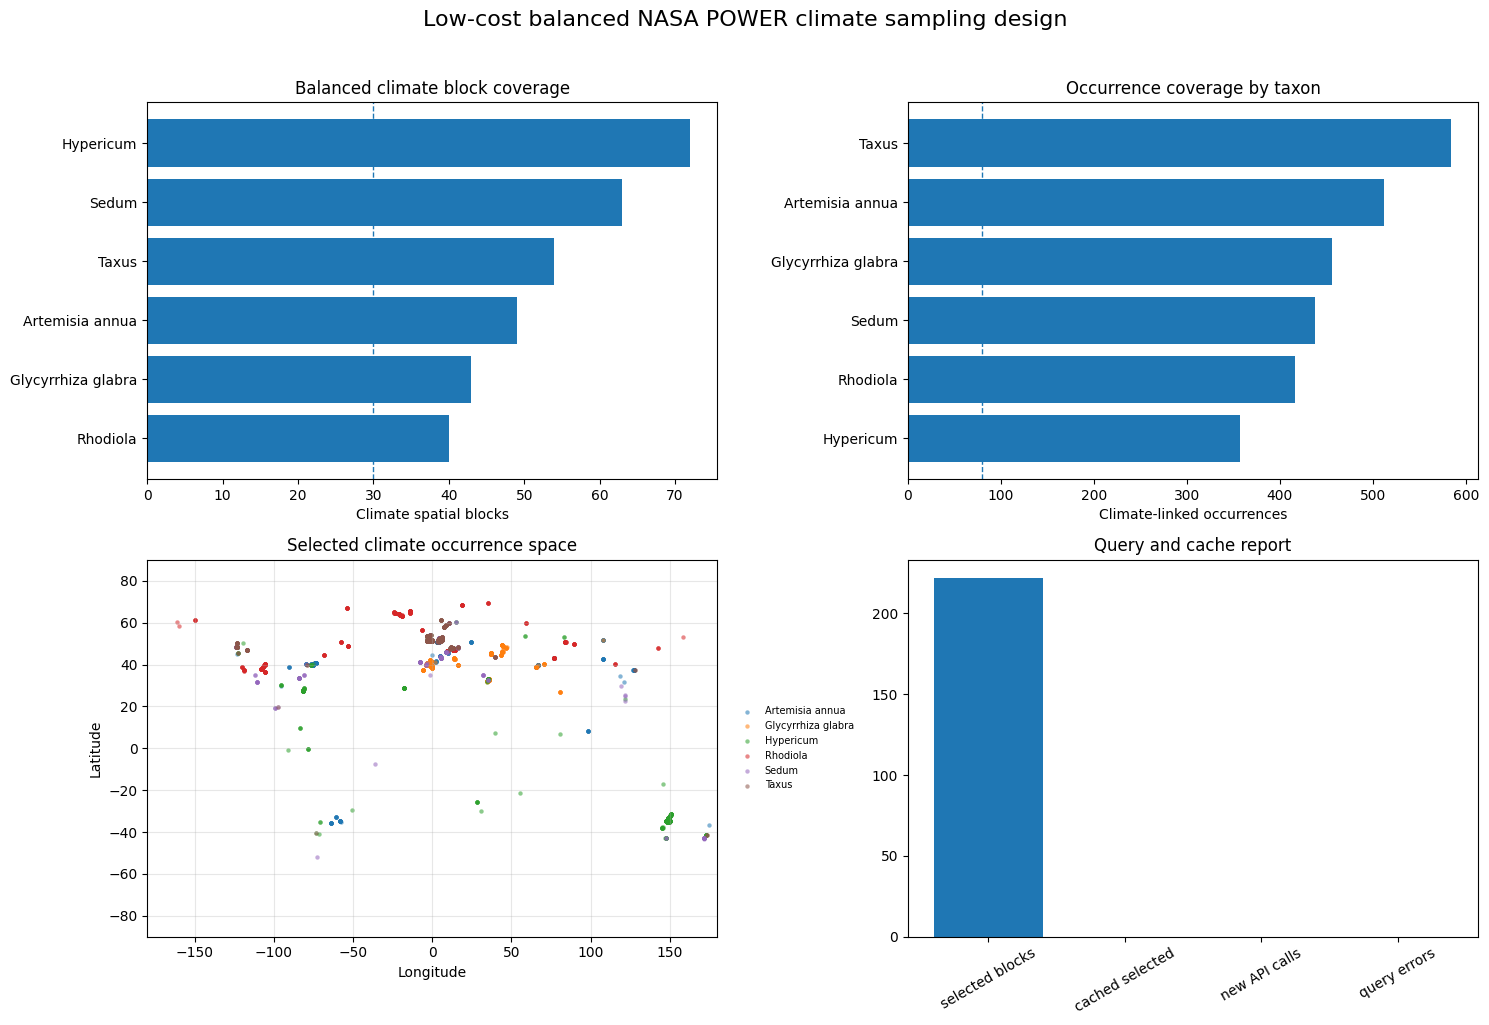

Saved: /content/climate_medicinal_value_dataset_v1/figures/figure2C_climate_seasonal_profiles.png


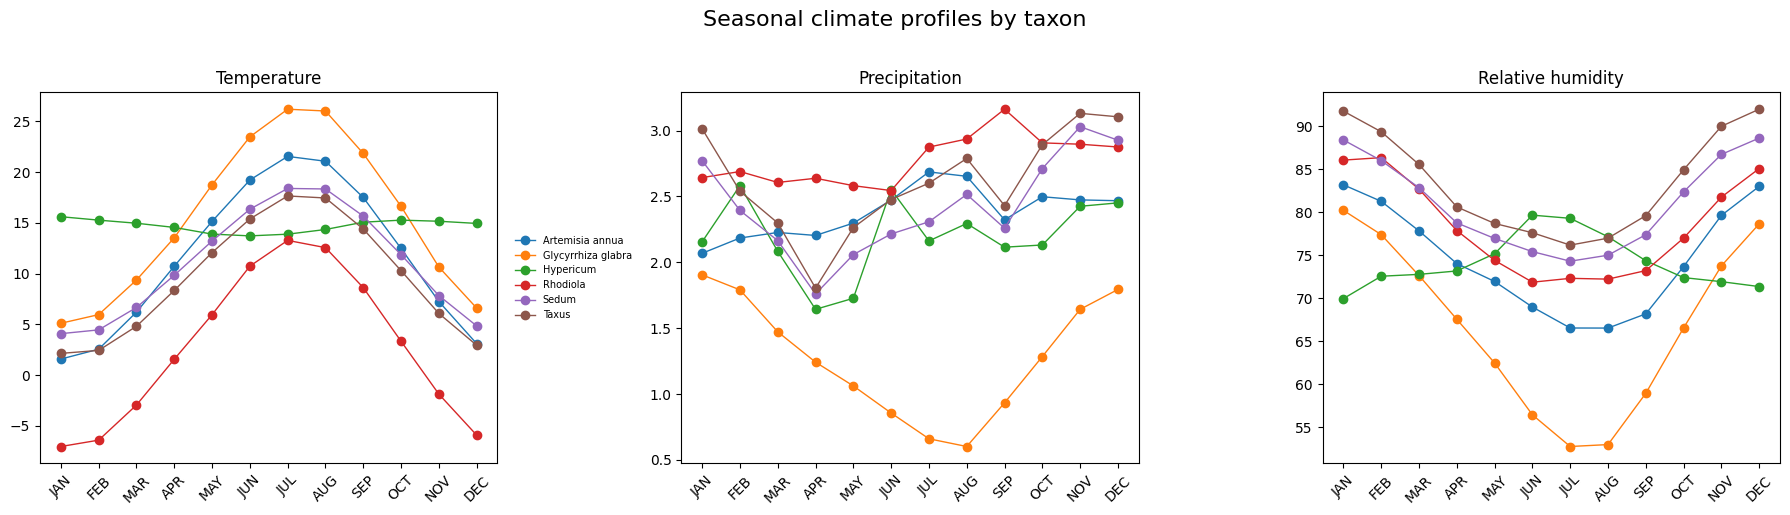

,file_role,path,required_for_notebook2,exists_and_nonempty,ready_for_notebook2_all_taxa,run_id,created_utc
0,occurrence_climate_features,/content/climate_medicinal_value_dataset_v1/de...,True,True,True,20260515T063115Z,2026-05-15T06:37:47+00:00
1,climate_point_features_wide,/content/climate_medicinal_value_dataset_v1/cl...,True,True,True,20260515T063115Z,2026-05-15T06:37:47+00:00
2,climate_point_features_long,/content/climate_medicinal_value_dataset_v1/cl...,True,True,True,20260515T063115Z,2026-05-15T06:37:47+00:00
3,climate_taxon_summary,/content/climate_medicinal_value_dataset_v1/de...,True,True,True,20260515T063115Z,2026-05-15T06:37:47+00:00
4,climate_spatial_block_features,/content/climate_medicinal_value_dataset_v1/de...,True,True,True,20260515T063115Z,2026-05-15T06:37:47+00:00
5,climate_coverage_by_taxon_v1,/content/climate_medicinal_value_dataset_v1/de...,True,True,True,20260515T063115Z,2026-05-15T06:37:47+00:00
6,target_taxa_config,/content/climate_medicinal_value_dataset_v1/me...,True,True,True,20260515T063115Z,2026-05-15T06:37:47+00:00
7,target_compounds_config,/content/climate_medicinal_value_dataset_v1/me...,True,True,True,20260515T063115Z,2026-05-15T06:37:47+00:00


/content/climate_medicinal_value_dataset_v1/derived/climate_notebook1C_qc_report.md


In [10]:
# ============================================================
# 9. Coverage, summaries, figures, and handoff
# ============================================================

coverage_by_taxon = (
    gbif_liberal_df
    .groupby(["taxon_id", "input_taxon"], as_index=False)
    .agg(total_liberal_occurrences=("gbif_key", "count"),
         total_liberal_spatial_blocks=("spatial_block_id", "nunique"))
)

sampled = (
    occ_climate_df
    .groupby(["taxon_id", "input_taxon"], as_index=False)
    .agg(sampled_occurrences_with_climate=("gbif_key", "count"),
         sampled_spatial_blocks_with_climate=("spatial_block_id", "nunique"),
         sampled_geo_strata=("geo_stratum", "nunique"))
)

coverage_by_taxon = coverage_by_taxon.merge(sampled, on=["taxon_id", "input_taxon"], how="left")
for c in ["sampled_occurrences_with_climate", "sampled_spatial_blocks_with_climate", "sampled_geo_strata"]:
    coverage_by_taxon[c] = coverage_by_taxon[c].fillna(0).astype(int)

coverage_by_taxon["pct_occurrences_sampled"] = (
    100 * coverage_by_taxon["sampled_occurrences_with_climate"] / coverage_by_taxon["total_liberal_occurrences"]
).round(2)

coverage_by_taxon["ready_for_notebook2"] = (
    (coverage_by_taxon["sampled_spatial_blocks_with_climate"] >= CONFIG["min_climate_blocks_per_taxon_for_notebook2"]) |
    (coverage_by_taxon["sampled_occurrences_with_climate"] >= CONFIG["min_occurrences_covered_per_taxon_for_notebook2"])
)

all_taxa_ready = bool(coverage_by_taxon["ready_for_notebook2"].all())
write_table(coverage_by_taxon, DIRS["derived"] / "climate_coverage_by_taxon_v1")

summary_rows = []
for taxon_id, sub in occ_climate_df.groupby("taxon_id"):
    meta = sub.iloc[0]
    row = {
        "taxon_id": taxon_id,
        "scientific_name": meta.get("input_taxon", ""),
        "family": meta.get("family", ""),
        "rank": meta.get("rank", ""),
        "priority": meta.get("priority", ""),
        "sampled_occurrences_with_climate": len(sub),
        "sampled_spatial_blocks_with_climate": sub["spatial_block_id"].nunique(),
        "sampled_geo_strata": sub["geo_stratum"].nunique(),
    }
    for c in climate_feature_cols:
        vals = pd.to_numeric(sub[c], errors="coerce")
        row[f"{c}__mean"] = vals.mean()
        row[f"{c}__sd"] = vals.std()
        row[f"{c}__median"] = vals.median()
        row[f"{c}__n"] = vals.notna().sum()
    summary_rows.append(row)

climate_taxon_summary_df = pd.DataFrame(summary_rows)
climate_taxon_summary_df = add_provenance(climate_taxon_summary_df, "derived from occurrence_climate_features", "taxon-level climate summaries")
write_table(climate_taxon_summary_df, DIRS["derived"] / "climate_taxon_summary")

block_summary = (
    occ_climate_df
    .groupby("spatial_block_id", as_index=False)
    .agg(n_occurrences=("gbif_key", "count"),
         n_taxa=("taxon_id", "nunique"),
         decimal_latitude=("block_centroid_latitude", "first"),
         decimal_longitude=("block_centroid_longitude", "first"),
         geo_stratum=("geo_stratum", "first"))
)

for c in climate_feature_cols:
    block_vals = occ_climate_df.groupby("spatial_block_id")[c].mean().reset_index()
    block_summary = block_summary.merge(block_vals, on="spatial_block_id", how="left")

block_summary = add_provenance(block_summary, "derived from occurrence_climate_features", "spatial-block climate features")
write_table(block_summary, DIRS["derived"] / "climate_spatial_block_features")

# QC figures
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.reshape(-1)

plot_df = coverage_by_taxon.sort_values("sampled_spatial_blocks_with_climate")
axes[0].barh(plot_df["input_taxon"], plot_df["sampled_spatial_blocks_with_climate"])
axes[0].axvline(CONFIG["min_climate_blocks_per_taxon_for_notebook2"], linestyle="--", linewidth=1)
axes[0].set_xlabel("Climate spatial blocks")
axes[0].set_title("Balanced climate block coverage")

plot_df = coverage_by_taxon.sort_values("sampled_occurrences_with_climate")
axes[1].barh(plot_df["input_taxon"], plot_df["sampled_occurrences_with_climate"])
axes[1].axvline(CONFIG["min_occurrences_covered_per_taxon_for_notebook2"], linestyle="--", linewidth=1)
axes[1].set_xlabel("Climate-linked occurrences")
axes[1].set_title("Occurrence coverage by taxon")

for taxon, sub in occ_climate_df.groupby("input_taxon"):
    axes[2].scatter(pd.to_numeric(sub["decimal_longitude"], errors="coerce"),
                    pd.to_numeric(sub["decimal_latitude"], errors="coerce"),
                    s=10, alpha=0.55, linewidths=0, label=taxon)
axes[2].set_xlim(-180, 180)
axes[2].set_ylim(-90, 90)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
axes[2].set_title("Selected climate occurrence space")
axes[2].legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))

cost_items = pd.Series({
    "selected blocks": len(point_df),
    "cached selected": int(point_df["already_cached"].sum()),
    "new API calls": int((~query_point_df["point_id"].apply(has_cached_climate)).sum()),
    "query errors": len(climate_error_df),
})
axes[3].bar(cost_items.index, cost_items.values)
axes[3].tick_params(axis="x", rotation=30)
axes[3].set_title("Query and cache report")

fig.suptitle("Low-cost balanced NASA POWER climate sampling design", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure1C_low_cost_climate_sampling_design")
plt.show()

# Seasonal profile figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
months = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
for ax, param, title in zip(axes, ["T2M", "PRECTOTCORR", "RH2M"], ["Temperature", "Precipitation", "Relative humidity"]):
    cols = [f"clim_{param}_{m}" for m in months if f"clim_{param}_{m}" in occ_climate_df.columns]
    if cols:
        for taxon, sub in occ_climate_df.groupby("input_taxon"):
            vals = sub[cols].apply(pd.to_numeric, errors="coerce").mean(axis=0).values
            ax.plot(range(len(cols)), vals, marker="o", linewidth=1, label=taxon)
        ax.set_xticks(range(len(cols)))
        ax.set_xticklabels([c.split("_")[-1] for c in cols], rotation=45)
    ax.set_title(title)
axes[0].legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.suptitle("Seasonal climate profiles by taxon", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure2C_climate_seasonal_profiles")
plt.show()

handoff_files = [
    {"file_role": "occurrence_climate_features", "path": str(DIRS["derived"] / "occurrence_climate_features.tsv"), "required_for_notebook2": True},
    {"file_role": "climate_point_features_wide", "path": str(DIRS["climate"] / "climate_point_features_wide.tsv"), "required_for_notebook2": True},
    {"file_role": "climate_point_features_long", "path": str(DIRS["climate"] / "climate_point_features_long.tsv"), "required_for_notebook2": True},
    {"file_role": "climate_taxon_summary", "path": str(DIRS["derived"] / "climate_taxon_summary.tsv"), "required_for_notebook2": True},
    {"file_role": "climate_spatial_block_features", "path": str(DIRS["derived"] / "climate_spatial_block_features.tsv"), "required_for_notebook2": True},
    {"file_role": "climate_coverage_by_taxon_v1", "path": str(DIRS["derived"] / "climate_coverage_by_taxon_v1.tsv"), "required_for_notebook2": True},
    {"file_role": "target_taxa_config", "path": str(DIRS["metadata"] / "target_taxa_config.tsv"), "required_for_notebook2": True},
    {"file_role": "target_compounds_config", "path": str(DIRS["metadata"] / "target_compounds_config.tsv"), "required_for_notebook2": True},
]
handoff_df = pd.DataFrame(handoff_files)
handoff_df["exists_and_nonempty"] = handoff_df["path"].apply(lambda x: pathlib.Path(x).exists() and pathlib.Path(x).stat().st_size > 0)
handoff_df["ready_for_notebook2_all_taxa"] = all_taxa_ready
handoff_df["run_id"] = RUN_ID
handoff_df["created_utc"] = utc_now()
write_table(handoff_df, DIRS["derived"] / "climate_notebook1C_handoff_manifest")

qc_lines = [
    "# Notebook 1C climate QC report",
    f"Run ID: {RUN_ID}",
    f"Raw GBIF records: {len(gbif_df)}",
    f"Liberal GBIF records: {len(gbif_liberal_df)}",
    f"Selected unique climate spatial blocks: {len(point_df)}",
    f"Climate query points loaded/queried: {len(query_point_df)}",
    f"Climate wide rows: {len(climate_features_wide_df)}",
    f"Occurrence-climate rows: {len(occ_climate_df)}",
    f"All taxa ready for Notebook 2C: {all_taxa_ready}",
    "",
    "NASA POWER values are gridded climatology estimates. Derived variables are bioclimatic-like, not official WorldClim BIO variables.",
    "",
    "Taxon coverage:",
]
qc_lines.extend(coverage_by_taxon.to_string(index=False).splitlines())
qc_path = DIRS["derived"] / "climate_notebook1C_qc_report.md"
qc_path.write_text("\n".join(qc_lines), encoding="utf-8")

display(handoff_df)
print(qc_path)

In [11]:
# ============================================================
# 10. Fast run manifest
# ============================================================

manifest_rows = []
skip_dirs = {"api_cache", "checkpoints"}

for path in PROJECT.rglob("*"):
    if not path.is_file():
        continue
    if any(part in skip_dirs for part in path.parts):
        continue
    try:
        manifest_rows.append({
            "path": str(path.relative_to(PROJECT)),
            "absolute_path": str(path),
            "bytes": path.stat().st_size,
            "modified_utc": dt.datetime.fromtimestamp(path.stat().st_mtime, tz=dt.timezone.utc).isoformat(timespec="seconds"),
            "run_id": RUN_ID,
        })
    except Exception as e:
        print("Skipping", path, e)

run_manifest_df = pd.DataFrame(manifest_rows).sort_values("path")
write_table(run_manifest_df, PROJECT / "run_file_manifest_fast")
run_manifest_df.head()

,path,absolute_path,bytes,modified_utc,run_id
29,climate/climate_low_cost_sampling_plan_by_taxo...,/content/climate_medicinal_value_dataset_v1/cl...,5475,2026-05-15T06:31:30+00:00,20260515T063115Z
23,climate/climate_low_cost_sampling_plan_by_taxo...,/content/climate_medicinal_value_dataset_v1/cl...,394,2026-05-15T06:31:30+00:00,20260515T063115Z
20,climate/climate_point_features_long.parquet,/content/climate_medicinal_value_dataset_v1/cl...,79003,2026-05-15T06:37:43+00:00,20260515T063115Z
25,climate/climate_point_features_long.tsv,/content/climate_medicinal_value_dataset_v1/cl...,3993338,2026-05-15T06:37:43+00:00,20260515T063115Z
27,climate/climate_point_features_wide.parquet,/content/climate_medicinal_value_dataset_v1/cl...,123802,2026-05-15T06:37:44+00:00,20260515T063115Z


In [12]:
import shutil
import zipfile

output_dir = PROJECT
zip_filename = output_dir / f"notebook_outputs_{RUN_ID}.zip"

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for _, row in handoff_df.iterrows():
        file_path = pathlib.Path(row['path'])
        if file_path.exists() and file_path.is_file():
            zipf.write(file_path, file_path.relative_to(output_dir))
        else:
            print(f"Warning: File not found or not a file: {file_path}")

print(f"All output files have been zipped to: {zip_filename}")
from google.colab import files
files.download(zip_filename)

All output files have been zipped to: /content/climate_medicinal_value_dataset_v1/notebook_outputs_20260515T063115Z.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>